# 05 · Comparação final e modelo de produção

As redes neurais valem a complexidade? Este notebook coloca lado a lado, no **mesmo
conjunto de teste** e com o **mesmo critério de limiar** (sensibilidade ≥ 80 % na
validação):

| Família | Modelo |
|:--|:--|
| Linha de base clássica | Regressão logística |
| Linha de base forte para dados tabulares | Gradient Boosting (HistGradientBoosting) |
| Rede neural do zero | MLP em NumPy (notebook 01) |
| Rede neural | MLP em Keras (notebook 02) |
| Rede neural | MLP em PyTorch (notebook 03) |

No fim, o modelo final em Keras é treinado e gravado em `models/` para a aplicação
Streamlit.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from src import config
from src.data.dados import preparar
from src.model import avaliacao, mlp_keras, mlp_torch
from src.model.mlp_numpy import MLPNumpy
from src.model.treino import ARQUITETURA, carregar_modelo_final, treinar_modelo_final
from src.utils import graficos
from src.utils.io import configurar_estilo, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "05-comparacao-final"
particao = preparar()
P = particao

In [2]:
prob_val, prob_teste = {}, {}

logit = LogisticRegression(max_iter=1000).fit(P.X_treino, P.y_treino)
prob_val["Regressão logística"] = logit.predict_proba(P.X_val)[:, 1]
prob_teste["Regressão logística"] = logit.predict_proba(P.X_teste)[:, 1]

gb = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=500, early_stopping=True, random_state=config.SEMENTE
).fit(P.X_treino, P.y_treino)
prob_val["Gradient Boosting"] = gb.predict_proba(P.X_val)[:, 1]
prob_teste["Gradient Boosting"] = gb.predict_proba(P.X_teste)[:, 1]

rede_np = MLPNumpy(P.n_entradas, ocultas=(32, 16), taxa=0.05).fit(
    P.X_treino, P.y_treino, P.X_val, P.y_val, epocas=150, paciencia=10)
prob_val["MLP NumPy"] = rede_np.predict_proba(P.X_val)
prob_teste["MLP NumPy"] = rede_np.predict_proba(P.X_teste)

# A rede Keras da comparação é o próprio modelo final gravado para a aplicação:
# assim as métricas desta tabela e as do app são as mesmas.
metadados = treinar_modelo_final(particao)
rede_keras, _, _ = carregar_modelo_final()
prob_val["MLP Keras"] = mlp_keras.prever(rede_keras, P.X_val)
prob_teste["MLP Keras"] = mlp_keras.prever(rede_keras, P.X_teste)

rede_torch = mlp_torch.CardioNet(P.n_entradas, ocultas=ARQUITETURA["ocultas"], dropout=ARQUITETURA["dropout"])
mlp_torch.treinar(rede_torch, P.X_treino, P.y_treino, P.X_val, P.y_val, disp=torch.device("cpu"))
prob_val["MLP PyTorch"] = mlp_torch.prever(rede_torch, P.X_val)
prob_teste["MLP PyTorch"] = mlp_torch.prever(rede_torch, P.X_teste)

resultados = {}
for nome in prob_teste:
    limiar = avaliacao.escolher_limiar(P.y_val, prob_val[nome])
    resultados[nome] = avaliacao.metricas(P.y_teste, prob_teste[nome], limiar)

comparacao = avaliacao.tabela_comparativa(resultados)
salvar_tabela(comparacao, SECAO, "comparacao-teste")
comparacao

,auc_roc,auc_pr,acuracia,sensibilidade,especificidade,precisao,f1,brier,limiar
Gradient Boosting,0.8027,0.7834,0.7197,0.8115,0.6299,0.6822,0.7413,0.1795,0.3739
MLP PyTorch,0.8024,0.7859,0.7195,0.8112,0.6297,0.6821,0.7410,0.1796,0.3709
MLP Keras,0.8014,0.7860,0.7176,0.8078,0.6293,0.6809,0.7389,0.1803,0.3820
MLP NumPy,0.8009,0.7827,0.7165,0.8112,0.6238,0.6786,0.7390,0.1803,0.3845
Regressão logística,0.7943,0.7782,0.7129,0.8041,0.6236,0.6766,0.7349,0.1857,0.3981


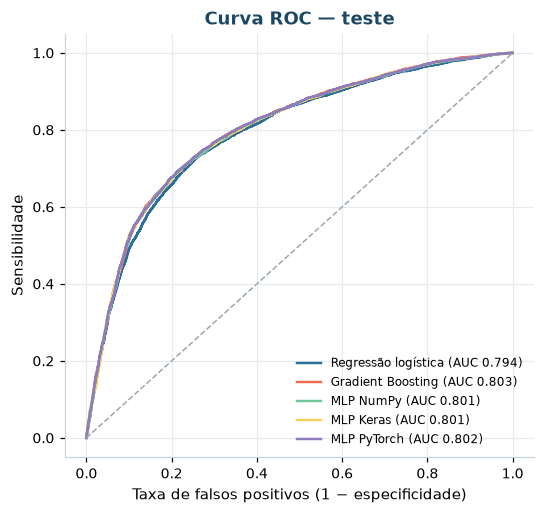

In [3]:
fig, dados = graficos.curvas_roc(prob_teste, P.y_teste)
salvar_figura(fig, SECAO, "roc-teste", dados.iloc[::20])
plt.show()

### Intervalo de confiança da AUC (bootstrap)

Diferenças na terceira casa decimal podem ser só acaso da amostra de teste. Reamostrar o
teste 500 vezes mostra a incerteza de cada AUC.

### Diferenças pareadas

Intervalos calculados separadamente para cada modelo se sobrepõem mesmo quando um modelo é
de fato melhor, porque boa parte da incerteza vem da amostra (pacientes fáceis ou
difíceis) e é comum aos dois. O **bootstrap pareado** avalia os dois modelos nos mesmos
pacientes reamostrados e mede só a diferença entre eles: se o IC 95 % da diferença não
contém zero, a diferença é real.

In [4]:
pares = [
    ("Gradient Boosting", "MLP Keras"),
    ("MLP PyTorch", "MLP Keras"),
    ("MLP Keras", "MLP NumPy"),
    ("MLP Keras", "Regressão logística"),
    ("Gradient Boosting", "Regressão logística"),
]
diferencas = pd.DataFrame(
    {
        f"{a} − {b}": avaliacao.bootstrap_diferenca_auc(P.y_teste, prob_teste[a], prob_teste[b])
        for a, b in pares
    }
).T
diferencas[["diferenca", "ic95_inf", "ic95_sup"]] = diferencas[["diferenca", "ic95_inf", "ic95_sup"]].astype(float).round(4)
salvar_tabela(diferencas, SECAO, "auc-diferenca-pareada")
diferencas

,diferenca,ic95_inf,ic95_sup,significativa
Gradient Boosting − MLP Keras,0.0013,-0.0002,0.0029,False
MLP PyTorch − MLP Keras,0.0010,0.0001,0.0018,True
MLP Keras − MLP NumPy,0.0005,-0.0007,0.0017,False
MLP Keras − Regressão logística,0.0071,0.0048,0.0093,True
Gradient Boosting − Regressão logística,0.0084,0.0059,0.0109,True


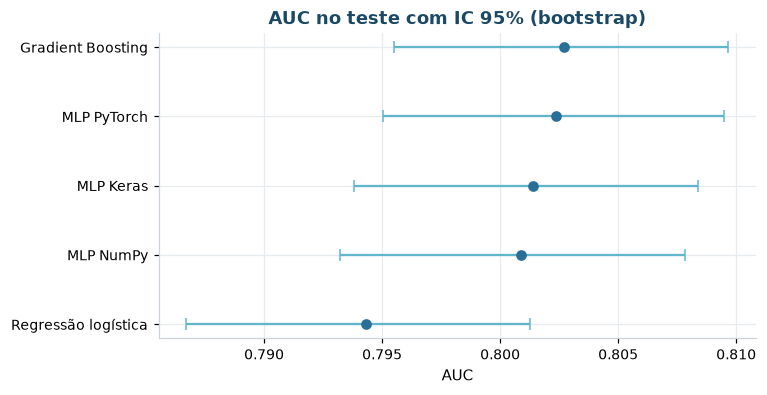

,auc,ic95_inf,ic95_sup
modelo,,,
Gradient Boosting,0.8027,0.7955,0.8097
MLP PyTorch,0.8024,0.7950,0.8095
MLP Keras,0.8014,0.7938,0.8084
MLP NumPy,0.8009,0.7932,0.8078
Regressão logística,0.7943,0.7867,0.8013


In [5]:
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(config.SEMENTE)
n = len(P.y_teste)
amostras = [rng.integers(0, n, n) for _ in range(500)]
linhas = []
for nome, p in prob_teste.items():
    aucs = [roc_auc_score(P.y_teste[i], p[i]) for i in amostras]
    linhas.append({"modelo": nome, "auc": roc_auc_score(P.y_teste, p),
                   "ic95_inf": np.percentile(aucs, 2.5), "ic95_sup": np.percentile(aucs, 97.5)})
ic = pd.DataFrame(linhas).set_index("modelo").sort_values("auc", ascending=False)
salvar_tabela(ic.round(4), SECAO, "auc-bootstrap")

fig, eixo = plt.subplots(figsize=(7, 3.6))
ordem = ic.sort_values("auc")
eixo.errorbar(ordem["auc"], ordem.index, xerr=[ordem["auc"] - ordem["ic95_inf"], ordem["ic95_sup"] - ordem["auc"]],
              fmt="o", color=config.AZUL_COBALTO, ecolor=config.AZUL_CLARO, capsize=4)
eixo.set(title="AUC no teste com IC 95% (bootstrap)", xlabel="AUC")
salvar_figura(fig, SECAO, "auc-bootstrap", ordem)
plt.show()
ic.round(4)

### Calibração: a probabilidade de 70 % quer dizer 70 %?

A AUC mede só se a rede **ordena** bem os pacientes. Mas a aplicação mostra a
probabilidade em si ("risco de 70 %"), então ela precisa ser **calibrada**: entre os
pacientes a quem a rede atribui cerca de 70 %, cerca de 70 % devem de fato ter a doença.
O diagrama de confiabilidade agrupa os pacientes do teste em 10 faixas de probabilidade
prevista e compara com a proporção real de doentes em cada faixa; a diagonal é a
calibração perfeita. O escore de Brier resume o erro quadrático das probabilidades
(quanto menor, melhor).

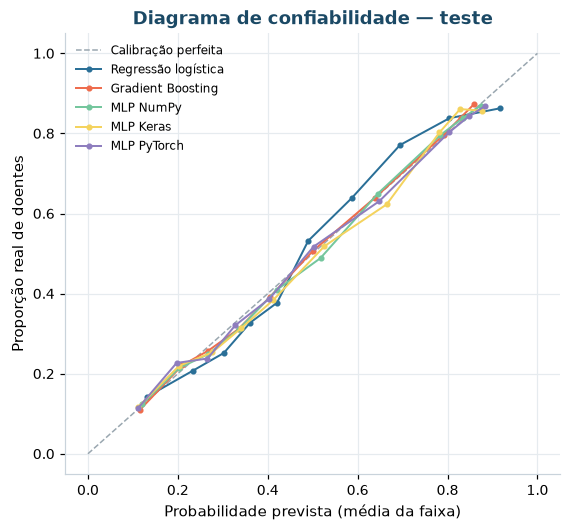

,brier,erro_calibracao_medio,maior_desvio
modelo,,,
Gradient Boosting,0.1795,0.0101,0.0235
MLP PyTorch,0.1796,0.0137,0.0296
MLP Keras,0.1803,0.0222,0.0417
MLP NumPy,0.1803,0.0123,0.0287
Regressão logística,0.1857,0.0423,0.0768


In [6]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, eixo = plt.subplots(figsize=(5.8, 5.2))
eixo.plot([0, 1], [0, 1], linestyle="--", color="#9AA7B0", linewidth=1, label="Calibração perfeita")
linhas, pontos = [], []
for (nome, p), cor in zip(prob_teste.items(), config.PALETA):
    real, previsto = calibration_curve(P.y_teste, p, n_bins=10, strategy="quantile")
    eixo.plot(previsto, real, marker="o", markersize=3, linewidth=1.3, color=cor, label=nome)
    pontos.append(pd.DataFrame({"modelo": nome, "previsto": previsto, "real": real}))
    linhas.append({
        "modelo": nome,
        "brier": brier_score_loss(P.y_teste, p),
        "erro_calibracao_medio": np.mean(np.abs(previsto - real)),
        "maior_desvio": np.max(np.abs(previsto - real)),
    })
eixo.set(title="Diagrama de confiabilidade — teste", xlabel="Probabilidade prevista (média da faixa)",
         ylabel="Proporção real de doentes")
eixo.legend(fontsize=8)
calibracao = pd.DataFrame(linhas).set_index("modelo").sort_values("brier").round(4)
salvar_figura(fig, SECAO, "calibracao", pd.concat(pontos, ignore_index=True))
salvar_tabela(calibracao, SECAO, "calibracao-resumo")
plt.show()
calibracao

Todos os modelos estão **bem calibrados**: as curvas acompanham a diagonal, com erro médio
de 1 a 2 pontos percentuais para as redes e o Gradient Boosting. A rede Keras superestima
um pouco o risco na faixa intermediária (prevê ~66 % onde a proporção real é ~62 %),
um desvio pequeno. A regressão logística é a pior calibrada (desvio de até ~8 pontos), porque sua
fronteira linear não acompanha a saturação do risco em pressões altas.

Para a aplicação isso é importante: quando ela mostra "risco de 70 %", o número pode ser
lido como uma frequência real. Não foi preciso recalibrar (com Platt ou regressão
isotônica), e o fato de a rede final não usar `class_weight` ajuda nisso, porque pesos de classe
distorceriam as probabilidades.

## Leitura dos resultados

O Gradient Boosting e as três redes ficam a no máximo ≈ 0,002 de AUC uns dos outros. Com
13.711 pacientes, o bootstrap pareado é sensível o bastante para detectar diferenças de
0,001, e **qual** par cruza a linha da significância muda de uma execução para outra (numa,
Gradient Boosting − Keras; noutra, PyTorch − Keras). É uma boa lição: **significância
estatística não é relevância prática**. Uma diferença de 0,001 de AUC não muda nenhuma
decisão de triagem. A regressão logística fica atrás
(0,794), e aqui o teste pareado mostra que a diferença, embora pequena (≈ 0,008), **é
real**: o IC da diferença fica inteiro acima de zero, coisa que os intervalos separados,
sobrepostos, não deixavam ver. As relações não lineares — a saturação da pressão, a
interação com a idade — valem algo, mas pouco.

Isso é esperado em dados **tabulares, com poucas variáveis e rótulos ruidosos**: o limite
vem da informação disponível, não da capacidade do modelo.

O que a rede neural traz, então?

* desempenho praticamente no patamar do melhor modelo clássico para dados tabulares — mas
  não acima dele;
* escore de Brier um pouco melhor que o da regressão logística (probabilidades mais
  próximas do observado), útil para um limiar clínico;
* uma base para crescer: se a organização passar a registrar séries temporais de pressão
  ou exames de imagem, redes recorrentes ou convolucionais aproveitam esses dados, e o
  Gradient Boosting não.

Se o critério fosse só desempenho na base atual, o Gradient Boosting seria a escolha
natural: marginalmente melhor e mais simples de operar.

## Modelo final

Treinado com a arquitetura escolhida no notebook 04 e gravado em `models/` logo no início da
comparação (é a mesma rede "MLP Keras" da tabela).

In [7]:
# Gravado na primeira célula de modelos; aqui, as métricas nos dois limiares.
pd.DataFrame({
    "limiar 0,50": metadados["teste_limiar_05"],
    f"limiar {metadados['limiar']:.2f}": metadados["teste_limiar_escolhido"],
}).round(4)

,"limiar 0,50",limiar 0.38
limiar,0.5000,0.3820
auc_roc,0.8014,0.8014
auc_pr,0.7860,0.7860
acuracia,0.7382,0.7176
sensibilidade,0.7096,0.8078
especificidade,0.7663,0.6293
precisao,0.7483,0.6809
f1,0.7285,0.7389
brier,0.1803,0.1803
vp,4814.0000,5480.0000
